# Script huấn luyện

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
TRANSFORM_DATA_DIR = "/content/drive/MyDrive/Chotot Project/TransformData"
RAW_DATA_DIR = "/content/drive/MyDrive/Chotot Project/RawData"

In [3]:
"""
Real Estate Price Prediction - Linear Regression Models Training Script
Target: log_price
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# Linear Regression Models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    BayesianRidge,
    HuberRegressor,
    SGDRegressor,
    PassiveAggressiveRegressor
)
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR, LinearSVR
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    ExtraTreesRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


class RealEstatePricePredictor:
    """
    Comprehensive Real Estate Price Prediction System
    """

    def __init__(self, data_path):
        """
        Initialize the predictor

        Parameters:
        -----------
        data_path : str
            Path to the CSV file containing real estate data
        """
        self.data_path = data_path
        self.df = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.preprocessor = None
        self.models = {}
        self.results = {}

        # Column lists will be populated after loading data
        self.numeric_features = None
        self.categorical_features = None

        self.target = 'log_price'

    def load_data(self):
        """Load and perform initial data exploration"""
        print("=" * 80)
        print("LOADING DATA")
        print("=" * 80)

        self.df = pd.read_csv(self.data_path)
        print(f"Dataset shape: {self.df.shape}")
        print(f"\nTarget variable (log_price) statistics:")
        print(self.df[self.target].describe())
        print(f"\nMissing values summary:")
        missing = self.df.isnull().sum()
        missing = missing[missing > 0].sort_values(ascending=False)
        if len(missing) > 0:
            print(missing)
        else:
            print("No missing values!")

        # Automatically detect feature types
        self._detect_features()

        return self

    def _detect_features(self):
        """Automatically detect numeric and categorical features"""
        # Get all columns except target
        all_columns = [col for col in self.df.columns if col != self.target]

        # Detect numeric features (int64, float64)
        self.numeric_features = self.df[all_columns].select_dtypes(
            include=['int64', 'float64', 'int32', 'float32']
        ).columns.tolist()

        # Detect categorical features (object type, bool, category)
        # We'll convert all non-numeric types to categorical
        self.categorical_features = self.df[all_columns].select_dtypes(
            include=['object', 'category', 'bool']
        ).columns.tolist()

        print(f"\n{'=' * 80}")
        print("FEATURE DETECTION")
        print(f"{'=' * 80}")
        print(f"Numeric features ({len(self.numeric_features)}): {self.numeric_features}")
        print(f"\nCategorical features ({len(self.categorical_features)}): {self.categorical_features}")

        # Show data types for categorical features to help debug
        if len(self.categorical_features) > 0:
            print(f"\nCategorical feature types:")
            for col in self.categorical_features[:10]:  # Show first 10
                dtype = self.df[col].dtype
                unique_types = set(type(x).__name__ for x in self.df[col].dropna().unique()[:5])
                print(f"  {col}: dtype={dtype}, sample value types={unique_types}")

        # Validate that we found features
        if len(self.numeric_features) == 0 and len(self.categorical_features) == 0:
            raise ValueError("No features detected! Please check your data.")

        return self

    def preprocess_data(self, test_size=0.2):
        """
        Preprocess the data including handling missing values, encoding, and scaling

        Parameters:
        -----------
        test_size : float
            Proportion of dataset to include in test split
        """
        print("\n" + "=" * 80)
        print("PREPROCESSING DATA")
        print("=" * 80)

        # Validate that features have been detected
        if self.numeric_features is None or self.categorical_features is None:
            raise ValueError("Features not detected. Please run load_data() first.")

        # Verify all features exist in the dataframe
        missing_numeric = [f for f in self.numeric_features if f not in self.df.columns]
        missing_categorical = [f for f in self.categorical_features if f not in self.df.columns]

        if missing_numeric:
            print(f"WARNING: Numeric features not found in data: {missing_numeric}")
            self.numeric_features = [f for f in self.numeric_features if f in self.df.columns]

        if missing_categorical:
            print(f"WARNING: Categorical features not found in data: {missing_categorical}")
            self.categorical_features = [f for f in self.categorical_features if f in self.df.columns]

        # Convert categorical columns to string to handle mixed types
        print("\nConverting categorical features to string type...")
        for col in self.categorical_features:
            if col in self.df.columns:
                self.df[col] = self.df[col].astype(str)

        print(self.df["is_main_street"].unique())

        # Separate features and target
        X = self.df.drop(columns=[self.target])
        y = self.df[self.target]

        # Split data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=RANDOM_STATE
        )

        print(f"Training set size: {self.X_train.shape}")
        print(f"Test set size: {self.X_test.shape}")

        # Create preprocessing pipelines
        transformers = []

        # Add numeric transformer if we have numeric features
        if len(self.numeric_features) > 0:
            numeric_transformer = Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', RobustScaler())  # Robust to outliers
            ])
            transformers.append(('num', numeric_transformer, self.numeric_features))
            print(f"\nNumeric features ({len(self.numeric_features)}): {self.numeric_features[:5]}...")

        # Add categorical transformer if we have categorical features
        if len(self.categorical_features) > 0:
            categorical_transformer = Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
            ])
            transformers.append(('cat', categorical_transformer, self.categorical_features))
            print(f"Categorical features ({len(self.categorical_features)}): {self.categorical_features[:5]}...")

        # Combine transformers
        if len(transformers) == 0:
            raise ValueError("No valid features found for preprocessing!")

        self.preprocessor = ColumnTransformer(
            transformers=transformers,
            remainder='drop'
        )

        print("\nPreprocessing pipeline created successfully!")

        return self

    def define_models(self):
        """Define all regression models to be trained"""
        print("\n" + "=" * 80)
        print("DEFINING MODELS")
        print("=" * 80)

        self.models = {
            # Linear Models
            'Linear Regression': LinearRegression(),
            'Ridge': Ridge(random_state=RANDOM_STATE),
            'Lasso': Lasso(random_state=RANDOM_STATE),
            'ElasticNet': ElasticNet(random_state=RANDOM_STATE),
            'Bayesian Ridge': BayesianRidge(),
            'Huber Regressor': HuberRegressor(),
            'SGD Regressor': SGDRegressor(random_state=RANDOM_STATE),

            # Kernel-based Models
            'SVR (RBF)': SVR(kernel='rbf'),
            'SVR (Linear)': LinearSVR(random_state=RANDOM_STATE),

            # Tree-based Models
            'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
            'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE),
            'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=RANDOM_STATE),

            # Gradient Boosting Variants
            'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
            'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),

            # Other Models
            'KNN': KNeighborsRegressor(n_jobs=-1),
        }

        print(f"Total models defined: {len(self.models)}")
        for model_name in self.models.keys():
            print(f"  - {model_name}")

        return self

    def train_and_evaluate(self):
        """Train all models and evaluate their performance"""
        print("\n" + "=" * 80)
        print("TRAINING AND EVALUATING MODELS")
        print("=" * 80)

        for model_name, model in self.models.items():
            print(f"\n{'=' * 40}")
            print(f"Training: {model_name}")
            print(f"{'=' * 40}")

            try:
                # Create pipeline
                pipeline = Pipeline([
                    ('preprocessor', self.preprocessor),
                    ('model', model)
                ])

                # Train
                pipeline.fit(self.X_train, self.y_train)

                # Predict
                y_train_pred = pipeline.predict(self.X_train)
                y_test_pred = pipeline.predict(self.X_test)

                # Calculate metrics
                train_metrics = self._calculate_metrics(self.y_train, y_train_pred)
                test_metrics = self._calculate_metrics(self.y_test, y_test_pred)

                # Cross-validation score (on training set)
                cv_scores = cross_val_score(
                    pipeline, self.X_train, self.y_train,
                    cv=5, scoring='r2', n_jobs=-1
                )

                # Store results
                self.results[model_name] = {
                    'pipeline': pipeline,
                    'train_metrics': train_metrics,
                    'test_metrics': test_metrics,
                    'cv_r2_mean': cv_scores.mean(),
                    'cv_r2_std': cv_scores.std()
                }

                # Print results
                print(f"Training R²: {train_metrics['r2']:.4f}")
                print(f"Test R²: {test_metrics['r2']:.4f}")
                print(f"Test RMSE: {test_metrics['rmse']:.4f}")
                print(f"Test MAE: {test_metrics['mae']:.4f}")
                print(f"CV R² (mean ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

            except Exception as e:
                print(f"Error training {model_name}: {str(e)}")
                continue

        print("\n" + "=" * 80)
        print("TRAINING COMPLETED")
        print("=" * 80)

        return self

    def _calculate_metrics(self, y_true, y_pred):
        """Calculate evaluation metrics"""
        return {
            'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
            'mae': mean_absolute_error(y_true, y_pred),
            'r2': r2_score(y_true, y_pred),
            'mape': mean_absolute_percentage_error(y_true, y_pred) * 100
        }

    def display_results_summary(self):
        """Display comprehensive results summary"""
        print("\n" + "=" * 80)
        print("RESULTS SUMMARY")
        print("=" * 80)

        # Create summary dataframe
        summary_data = []
        for model_name, result in self.results.items():
            summary_data.append({
                'Model': model_name,
                'Train R²': result['train_metrics']['r2'],
                'Test R²': result['test_metrics']['r2'],
                'CV R² (mean)': result['cv_r2_mean'],
                'Test RMSE': result['test_metrics']['rmse'],
                'Test MAE': result['test_metrics']['mae'],
                'Test MAPE (%)': result['test_metrics']['mape']
            })

        summary_df = pd.DataFrame(summary_data)
        summary_df = summary_df.sort_values('Test R²', ascending=False)

        print("\n" + summary_df.to_string(index=False))

        # Best model
        best_model_name = summary_df.iloc[0]['Model']
        best_r2 = summary_df.iloc[0]['Test R²']
        print(f"\n{'=' * 80}")
        print(f"BEST MODEL: {best_model_name} (Test R² = {best_r2:.4f})")
        print(f"{'=' * 80}")

        return summary_df

    def grid_search_top_models(self, top_n=3):
        """
        Perform grid search on top N models

        Parameters:
        -----------
        top_n : int
            Number of top models to tune
        """
        print("\n" + "=" * 80)
        print(f"GRID SEARCH ON TOP {top_n} MODELS")
        print("=" * 80)

        # Get top models
        summary_data = []
        for model_name, result in self.results.items():
            summary_data.append({
                'Model': model_name,
                'Test R²': result['test_metrics']['r2']
            })
        summary_df = pd.DataFrame(summary_data).sort_values('Test R²', ascending=False)
        top_models = summary_df.head(top_n)['Model'].tolist()

        # Define parameter grids
        param_grids = {
            'Ridge': {
                'model__alpha': [0.1, 1.0, 10.0, 100.0],
                'model__solver': ['auto', 'svd', 'lsqr']
            },
            'Lasso': {
                'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
                'model__max_iter': [1000, 5000]
            },
            'ElasticNet': {
                'model__alpha': [0.001, 0.01, 0.1, 1.0],
                'model__l1_ratio': [0.2, 0.5, 0.8],
                'model__max_iter': [1000, 5000]
            },
            'Random Forest': {
                'model__n_estimators': [100, 200],
                'model__max_depth': [10, 20, 30],
                'model__min_samples_split': [2, 5, 10],
                'model__min_samples_leaf': [1, 2, 4]
            },
            'Gradient Boosting': {
                'model__n_estimators': [100, 200],
                'model__learning_rate': [0.01, 0.05, 0.1],
                'model__max_depth': [3, 5, 7],
                'model__min_samples_split': [2, 5]
            },
            'XGBoost': {
                'model__n_estimators': [100, 200],
                'model__learning_rate': [0.01, 0.05, 0.1],
                'model__max_depth': [3, 5, 7],
                'model__subsample': [0.8, 1.0],
                'model__colsample_bytree': [0.8, 1.0]
            },
            'LightGBM': {
                'model__n_estimators': [100, 200],
                'model__learning_rate': [0.01, 0.05, 0.1],
                'model__max_depth': [3, 5, 7, -1],
                'model__num_leaves': [31, 50, 100],
                'model__subsample': [0.8, 1.0]
            },
            'SVR (RBF)': {
                'model__C': [0.1, 1, 10, 100],
                'model__gamma': ['scale', 'auto', 0.001, 0.01],
                'model__epsilon': [0.01, 0.1, 0.2]
            },
            'KNN': {
                'model__n_neighbors': [3, 5, 7, 9, 11],
                'model__weights': ['uniform', 'distance'],
                'model__p': [1, 2]
            }
        }

        tuned_results = {}

        for model_name in top_models:
            if model_name not in param_grids:
                print(f"\nSkipping {model_name} - no parameter grid defined")
                continue

            print(f"\n{'=' * 40}")
            print(f"Grid Search: {model_name}")
            print(f"{'=' * 40}")

            try:
                # Create pipeline
                pipeline = Pipeline([
                    ('preprocessor', self.preprocessor),
                    ('model', self.models[model_name])
                ])

                # Grid search
                grid_search = GridSearchCV(
                    pipeline,
                    param_grids[model_name],
                    cv=5,
                    scoring='r2',
                    n_jobs=-1,
                    verbose=1
                )

                grid_search.fit(self.X_train, self.y_train)

                # Evaluate best model
                y_train_pred = grid_search.predict(self.X_train)
                y_test_pred = grid_search.predict(self.X_test)

                train_metrics = self._calculate_metrics(self.y_train, y_train_pred)
                test_metrics = self._calculate_metrics(self.y_test, y_test_pred)

                tuned_results[model_name] = {
                    'best_params': grid_search.best_params_,
                    'best_score': grid_search.best_score_,
                    'pipeline': grid_search.best_estimator_,
                    'train_metrics': train_metrics,
                    'test_metrics': test_metrics
                }

                print(f"\nBest Parameters: {grid_search.best_params_}")
                print(f"Best CV R²: {grid_search.best_score_:.4f}")
                print(f"Test R²: {test_metrics['r2']:.4f}")
                print(f"Test RMSE: {test_metrics['rmse']:.4f}")

            except Exception as e:
                print(f"Error in grid search for {model_name}: {str(e)}")
                continue

        # Display tuned results
        print("\n" + "=" * 80)
        print("TUNED MODELS SUMMARY")
        print("=" * 80)

        tuned_summary = []
        for model_name, result in tuned_results.items():
            tuned_summary.append({
                'Model': model_name,
                'Best CV R²': result['best_score'],
                'Test R²': result['test_metrics']['r2'],
                'Test RMSE': result['test_metrics']['rmse'],
                'Test MAE': result['test_metrics']['mae']
            })

        if tuned_summary:
            tuned_df = pd.DataFrame(tuned_summary).sort_values('Test R²', ascending=False)
            print("\n" + tuned_df.to_string(index=False))

            # Save best tuned model
            best_tuned_name = tuned_df.iloc[0]['Model']
            self.best_model = tuned_results[best_tuned_name]['pipeline']
            self.best_model_name = f"{best_tuned_name} (Tuned)"

            print(f"\n{'=' * 80}")
            print(f"BEST TUNED MODEL: {best_tuned_name}")
            print(f"Best Parameters: {tuned_results[best_tuned_name]['best_params']}")
            print(f"{'=' * 80}")

        return tuned_results

    def plot_results(self, save_path='model_comparison.png', top_n=10, r2_threshold=None):
        """
        Plot model comparison, optionally filtering to show only top performers

        Parameters:
        -----------
        save_path : str
            Path to save the plot
        top_n : int, optional
            Number of top models to display. If None, shows all models.
        r2_threshold : float, optional
            Minimum R² score to include. Models below this are filtered out.
            If None, no threshold filtering is applied.
        """
        print("\n" + "=" * 80)
        print("GENERATING PLOTS")
        print("=" * 80)

        # Prepare data
        models_list = []
        test_r2_list = []
        test_rmse_list = []

        for model_name, result in self.results.items():
            models_list.append(model_name)
            test_r2_list.append(result['test_metrics']['r2'])
            test_rmse_list.append(result['test_metrics']['rmse'])

        # Filter models based on criteria
        filtered_indices = list(range(len(models_list)))

        # Apply R² threshold filter if specified
        if r2_threshold is not None:
            print(f"\nFiltering models with R² < {r2_threshold}")
            filtered_indices = [i for i in filtered_indices if test_r2_list[i] >= r2_threshold]
            removed_count = len(models_list) - len(filtered_indices)
            if removed_count > 0:
                print(f"Removed {removed_count} models below R² threshold")

        # Apply top_n filter if specified
        if top_n is not None and len(filtered_indices) > top_n:
            print(f"\nShowing top {top_n} models by R² score")
            # Sort by R² and take top N
            sorted_indices = sorted(filtered_indices, key=lambda i: test_r2_list[i], reverse=True)
            filtered_indices = sorted_indices[:top_n]

        # Apply filters
        models_list = [models_list[i] for i in filtered_indices]
        test_r2_list = [test_r2_list[i] for i in filtered_indices]
        test_rmse_list = [test_rmse_list[i] for i in filtered_indices]

        print(f"\nDisplaying {len(models_list)} models in comparison plot")

        if len(models_list) == 0:
            print("WARNING: No models meet the filtering criteria!")
            return self

        # Create plots
        fig, axes = plt.subplots(2, 1, figsize=(14, 10))

        # Plot 1: R² Score
        sorted_indices = np.argsort(test_r2_list)[::-1]
        sorted_models = [models_list[i] for i in sorted_indices]
        sorted_r2 = [test_r2_list[i] for i in sorted_indices]

        # Color code: green for positive R², red for negative
        colors_r2 = ['forestgreen' if r2 >= 0 else 'crimson' for r2 in sorted_r2]

        axes[0].barh(sorted_models, sorted_r2, color=colors_r2, alpha=0.7, edgecolor='black')
        axes[0].set_xlabel('R² Score', fontsize=12, fontweight='bold')
        axes[0].set_title('Model Comparison - R² Score (Higher is Better)', fontsize=14, fontweight='bold')
        axes[0].grid(axis='x', alpha=0.3, linestyle='--')
        axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1)

        # Add value labels on bars
        for i, (model, r2) in enumerate(zip(sorted_models, sorted_r2)):
            axes[0].text(r2 + (0.02 if r2 >= 0 else -0.02), i, f'{r2:.3f}',
                        va='center', ha='left' if r2 >= 0 else 'right', fontsize=9)

        # Plot 2: RMSE
        sorted_indices_rmse = np.argsort(test_rmse_list)
        sorted_models_rmse = [models_list[i] for i in sorted_indices_rmse]
        sorted_rmse = [test_rmse_list[i] for i in sorted_indices_rmse]

        # Color gradient: darker for better (lower) RMSE
        colors_rmse = plt.cm.Oranges(np.linspace(0.4, 0.9, len(sorted_rmse))[::-1])

        axes[1].barh(sorted_models_rmse, sorted_rmse, color=colors_rmse, edgecolor='black')
        axes[1].set_xlabel('RMSE', fontsize=12, fontweight='bold')
        axes[1].set_title('Model Comparison - RMSE (Lower is Better)', fontsize=14, fontweight='bold')
        axes[1].grid(axis='x', alpha=0.3, linestyle='--')

        # Add value labels on bars
        for i, (model, rmse) in enumerate(zip(sorted_models_rmse, sorted_rmse)):
            axes[1].text(rmse + 0.02, i, f'{rmse:.3f}', va='center', ha='left', fontsize=9)

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\nPlot saved to: {save_path}")

        # Print filtering summary
        if r2_threshold is not None or top_n is not None:
            print(f"\nFiltering Summary:")
            if r2_threshold is not None:
                print(f"  - R² threshold: >= {r2_threshold}")
            if top_n is not None:
                print(f"  - Top N models: {top_n}")
            print(f"  - Models displayed: {len(models_list)}")
            print(f"  - Best R²: {max(test_r2_list):.4f}")
            print(f"  - Worst R² (shown): {min(test_r2_list):.4f}")

        return self

    def plot_predictions(self, model_name=None, save_path='predictions_plot.png'):
        """Plot actual vs predicted values for a specific model"""
        if model_name is None:
            # Use best model
            summary_data = []
            for name, result in self.results.items():
                summary_data.append({
                    'Model': name,
                    'Test R²': result['test_metrics']['r2']
                })
            summary_df = pd.DataFrame(summary_data).sort_values('Test R²', ascending=False)
            model_name = summary_df.iloc[0]['Model']

        print(f"\nGenerating prediction plot for: {model_name}")

        pipeline = self.results[model_name]['pipeline']
        y_pred = pipeline.predict(self.X_test)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Scatter plot
        axes[0].scatter(self.y_test, y_pred, alpha=0.5, s=10)
        axes[0].plot([self.y_test.min(), self.y_test.max()],
                     [self.y_test.min(), self.y_test.max()],
                     'r--', lw=2)
        axes[0].set_xlabel('Actual log_price', fontsize=12)
        axes[0].set_ylabel('Predicted log_price', fontsize=12)
        axes[0].set_title(f'{model_name} - Actual vs Predicted', fontsize=14, fontweight='bold')
        axes[0].grid(alpha=0.3)

        # Residual plot
        residuals = self.y_test - y_pred
        axes[1].scatter(y_pred, residuals, alpha=0.5, s=10)
        axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
        axes[1].set_xlabel('Predicted log_price', fontsize=12)
        axes[1].set_ylabel('Residuals', fontsize=12)
        axes[1].set_title(f'{model_name} - Residual Plot', fontsize=14, fontweight='bold')
        axes[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Predictions plot saved to: {save_path}")

        return self

    def save_best_model(self, filepath='best_model.pkl'):
        """Save the best model to disk"""
        import joblib

        # Find best model
        summary_data = []
        for model_name, result in self.results.items():
            summary_data.append({
                'Model': model_name,
                'Test R²': result['test_metrics']['r2']
            })
        summary_df = pd.DataFrame(summary_data).sort_values('Test R²', ascending=False)
        best_model_name = summary_df.iloc[0]['Model']
        best_pipeline = self.results[best_model_name]['pipeline']

        joblib.dump(best_pipeline, filepath)
        print(f"\nBest model ({best_model_name}) saved to: {filepath}")

        return self

    def predict(self, X, model_name=None):
        """
        Make predictions on new data

        Parameters:
        -----------
        X : pd.DataFrame
            Input features (without target variable)
        model_name : str, optional
            Name of the model to use. If None, uses the best model.

        Returns:
        --------
        predictions : np.ndarray
            Predicted log_price values
        """
        if model_name is None:
            # Use best model
            summary_data = []
            for name, result in self.results.items():
                summary_data.append({
                    'Model': name,
                    'Test R²': result['test_metrics']['r2']
                })
            summary_df = pd.DataFrame(summary_data).sort_values('Test R²', ascending=False)
            model_name = summary_df.iloc[0]['Model']

        if model_name not in self.results:
            raise ValueError(f"Model '{model_name}' not found. Available models: {list(self.results.keys())}")

        pipeline = self.results[model_name]['pipeline']
        predictions = pipeline.predict(X)

        return predictions

    def predict_price(self, X, model_name=None, return_log=False):
        """
        Make price predictions on new data (converts from log10 scale)

        Parameters:
        -----------
        X : pd.DataFrame
            Input features (without target variable)
        model_name : str, optional
            Name of the model to use. If None, uses the best model.
        return_log : bool
            If True, returns log_price (log10). If False, returns actual price.

        Returns:
        --------
        predictions : np.ndarray
            Predicted price values
        """
        log_predictions = self.predict(X, model_name)

        if return_log:
            return log_predictions
        else:
            # Convert from log10 to actual price
            return 10 ** log_predictions

    def predict_single(self, property_data, model_name=None, return_confidence=False):
        """
        Make prediction for a single property

        Parameters:
        -----------
        property_data : dict or pd.Series
            Dictionary or Series with property features
        model_name : str, optional
            Name of the model to use. If None, uses the best model.
        return_confidence : bool
            If True, returns prediction with confidence interval (for ensemble models)

        Returns:
        --------
        prediction : float or dict
            Predicted price (or dict with prediction and confidence if return_confidence=True)
        """
        # Convert to DataFrame
        if isinstance(property_data, dict):
            X = pd.DataFrame([property_data])
        elif isinstance(property_data, pd.Series):
            X = pd.DataFrame([property_data])
        else:
            raise ValueError("property_data must be a dict or pd.Series")

        # Make prediction
        log_price = self.predict(X, model_name)[0]
        price = 10 ** log_price  # Convert from log10 to actual price

        if return_confidence:
            # Calculate confidence interval for ensemble models
            if model_name is None:
                summary_data = []
                for name, result in self.results.items():
                    summary_data.append({
                        'Model': name,
                        'Test R²': result['test_metrics']['r2']
                    })
                summary_df = pd.DataFrame(summary_data).sort_values('Test R²', ascending=False)
                model_name = summary_df.iloc[0]['Model']

            pipeline = self.results[model_name]['pipeline']
            model = pipeline.named_steps['model']

            # For tree-based models, get prediction intervals using trees
            if hasattr(model, 'estimators_'):
                tree_predictions = []
                preprocessed_X = pipeline.named_steps['preprocessor'].transform(X)

                for estimator in model.estimators_:
                    if hasattr(estimator, 'predict'):
                        pred = estimator.predict(preprocessed_X)[0]
                    else:
                        pred = estimator.predict(preprocessed_X)[0]
                    tree_predictions.append(10 ** pred)  # Convert from log10

                confidence_lower = np.percentile(tree_predictions, 5)
                confidence_upper = np.percentile(tree_predictions, 95)

                return {
                    'predicted_price': price,
                    'log_price': log_price,
                    'confidence_interval_90': (confidence_lower, confidence_upper),
                    'model': model_name
                }
            else:
                # For non-ensemble models, use test RMSE as approximation
                test_rmse = self.results[model_name]['test_metrics']['rmse']
                confidence_lower = 10 ** (log_price - 1.96 * test_rmse)
                confidence_upper = 10 ** (log_price + 1.96 * test_rmse)

                return {
                    'predicted_price': price,
                    'log_price': log_price,
                    'confidence_interval_95': (confidence_lower, confidence_upper),
                    'model': model_name
                }

        return price

    def predict_batch(self, csv_path, output_path=None, model_name=None):
        """
        Make predictions on a batch of properties from CSV file

        Parameters:
        -----------
        csv_path : str
            Path to CSV file with property data
        output_path : str, optional
            Path to save predictions. If None, returns DataFrame.
        model_name : str, optional
            Name of the model to use. If None, uses the best model.

        Returns:
        --------
        results_df : pd.DataFrame
            DataFrame with original data plus predictions
        """
        # Load data
        df = pd.read_csv(csv_path)
        print(f"Loaded {len(df)} properties for prediction")

        # Make predictions
        log_predictions = self.predict(df, model_name)
        price_predictions = 10 ** log_predictions  # Convert from log10 to actual price

        # Add predictions to dataframe
        df['predicted_log_price'] = log_predictions
        df['predicted_price'] = price_predictions

        # Add model name
        if model_name is None:
            summary_data = []
            for name, result in self.results.items():
                summary_data.append({
                    'Model': name,
                    'Test R²': result['test_metrics']['r2']
                })
            summary_df = pd.DataFrame(summary_data).sort_values('Test R²', ascending=False)
            model_name = summary_df.iloc[0]['Model']

        df['model_used'] = model_name

        # Save if output path provided
        if output_path:
            df.to_csv(output_path, index=False)
            print(f"Predictions saved to: {output_path}")

        return df

    def predict_with_all_models(self, X):
        """
        Make predictions using all trained models

        Parameters:
        -----------
        X : pd.DataFrame
            Input features (without target variable)

        Returns:
        --------
        predictions_df : pd.DataFrame
            DataFrame with predictions from all models
        """
        all_predictions = {}

        for model_name in self.results.keys():
            try:
                predictions = self.predict(X, model_name)
                all_predictions[f'{model_name}_log_price'] = predictions
                all_predictions[f'{model_name}_price'] = 10 ** predictions  # Convert from log10
            except Exception as e:
                print(f"Error predicting with {model_name}: {str(e)}")
                continue

        predictions_df = pd.DataFrame(all_predictions)

        # Add ensemble predictions (average of all models)
        log_cols = [col for col in predictions_df.columns if col.endswith('_log_price')]
        predictions_df['ensemble_log_price'] = predictions_df[log_cols].mean(axis=1)
        predictions_df['ensemble_price'] = 10 ** predictions_df['ensemble_log_price']  # Convert from log10

        return predictions_df

    def explain_prediction(self, property_data, model_name=None, top_n_features=10):
        """
        Explain prediction by showing feature importance (for tree-based models)

        Parameters:
        -----------
        property_data : dict or pd.Series
            Dictionary or Series with property features
        model_name : str, optional
            Name of the model to use. Must be a tree-based model.
        top_n_features : int
            Number of top features to display

        Returns:
        --------
        explanation : dict
            Dictionary with prediction and feature importance
        """
        # Convert to DataFrame
        if isinstance(property_data, dict):
            X = pd.DataFrame([property_data])
        elif isinstance(property_data, pd.Series):
            X = pd.DataFrame([property_data])
        else:
            raise ValueError("property_data must be a dict or pd.Series")

        # Get model
        if model_name is None:
            summary_data = []
            for name, result in self.results.items():
                summary_data.append({
                    'Model': name,
                    'Test R²': result['test_metrics']['r2']
                })
            summary_df = pd.DataFrame(summary_data).sort_values('Test R²', ascending=False)
            model_name = summary_df.iloc[0]['Model']

        pipeline = self.results[model_name]['pipeline']
        model = pipeline.named_steps['model']

        # Make prediction
        prediction = self.predict_single(property_data, model_name, return_confidence=True)

        # Get feature importance
        if hasattr(model, 'feature_importances_'):
            # Get feature names after preprocessing
            preprocessor = pipeline.named_steps['preprocessor']

            # Get feature names from transformers
            feature_names = []

            # Numeric features
            feature_names.extend(self.numeric_features)

            # Categorical features (one-hot encoded)
            if hasattr(preprocessor.named_transformers_['cat'], 'named_steps'):
                encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
                if hasattr(encoder, 'get_feature_names_out'):
                    cat_features = encoder.get_feature_names_out(self.categorical_features)
                    feature_names.extend(cat_features)

            importances = model.feature_importances_

            # Match feature names with importances
            if len(feature_names) == len(importances):
                feature_importance = pd.DataFrame({
                    'feature': feature_names,
                    'importance': importances
                }).sort_values('importance', ascending=False).head(top_n_features)
            else:
                # Fallback: use generic names
                feature_importance = pd.DataFrame({
                    'feature': [f'feature_{i}' for i in range(len(importances))],
                    'importance': importances
                }).sort_values('importance', ascending=False).head(top_n_features)

            return {
                'prediction': prediction,
                'top_features': feature_importance.to_dict('records'),
                'model': model_name
            }
        else:
            return {
                'prediction': prediction,
                'message': f"Model {model_name} does not support feature importance",
                'model': model_name
            }

    @staticmethod
    def load_model(filepath):
        """
        Load a saved model from disk

        Parameters:
        -----------
        filepath : str
            Path to the saved model file

        Returns:
        --------
        model : sklearn.pipeline.Pipeline
            Loaded model pipeline
        """
        import joblib
        model = joblib.load(filepath)
        print(f"Model loaded from: {filepath}")
        return model

    @staticmethod
    def predict_from_saved_model(model_path, data_path, output_path=None):
        """
        Make predictions using a saved model

        Parameters:
        -----------
        model_path : str
            Path to saved model file
        data_path : str
            Path to CSV file with data to predict
        output_path : str, optional
            Path to save predictions

        Returns:
        --------
        results_df : pd.DataFrame
            DataFrame with predictions
        """
        import joblib

        # Load model
        model = joblib.load(model_path)
        print(f"Model loaded from: {model_path}")

        # Load data
        df = pd.read_csv(data_path)
        print(f"Loaded {len(df)} properties for prediction")

        # Make predictions
        log_predictions = model.predict(df)
        price_predictions = 10 ** log_predictions  # Convert from log10 to actual price

        # Add to dataframe
        df['predicted_log_price'] = log_predictions
        df['predicted_price'] = price_predictions

        # Save if output path provided
        if output_path:
            df.to_csv(output_path, index=False)
            print(f"Predictions saved to: {output_path}")

        return df

In [4]:
import os

# Huấn luyện với dữ liệu mua bán (s)

## Dữ liệu làm sạch

REAL ESTATE PRICE PREDICTION - LINEAR REGRESSION MODELS
Buy/Sell Cleaned Dataset
LOADING DATA
Dataset shape: (28690, 23)

Target variable (log_price) statistics:
count    28690.000000
mean         9.762696
std          0.298081
min          8.802774
25%          9.591065
50%          9.759668
75%          9.929419
max         10.740363
Name: log_price, dtype: float64

Missing values summary:
floornumber       27914
living_size       18163
floors            15612
length             8436
width              7860
is_main_street     7771
dtype: int64

FEATURE DETECTION
Numeric features (8): ['floornumber', 'floors', 'length', 'living_size', 'width', 'longitude', 'latitude', 'log_size']

Categorical features (14): ['area_name', 'category_name', 'is_main_street', 'apartment_type_name', 'property_legal_document_status', 'rooms_count', 'toilets_count', 'furnishing_sell_status', 'balconydirection_name', 'direction_name', 'house_type_name', 'commercial_type_name', 'land_type_name', 'property_stat

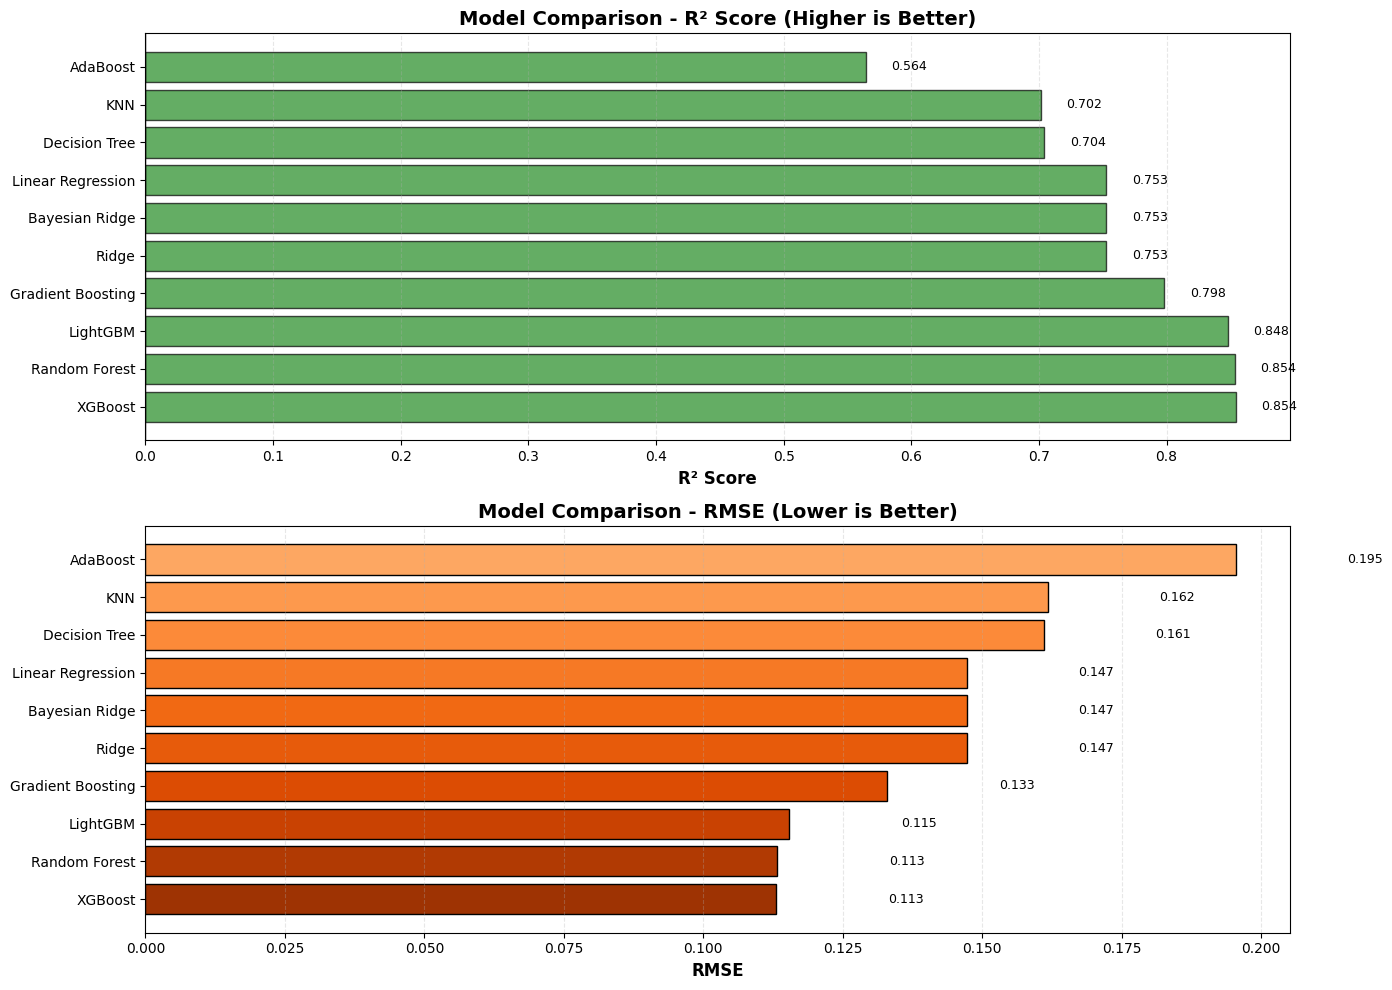

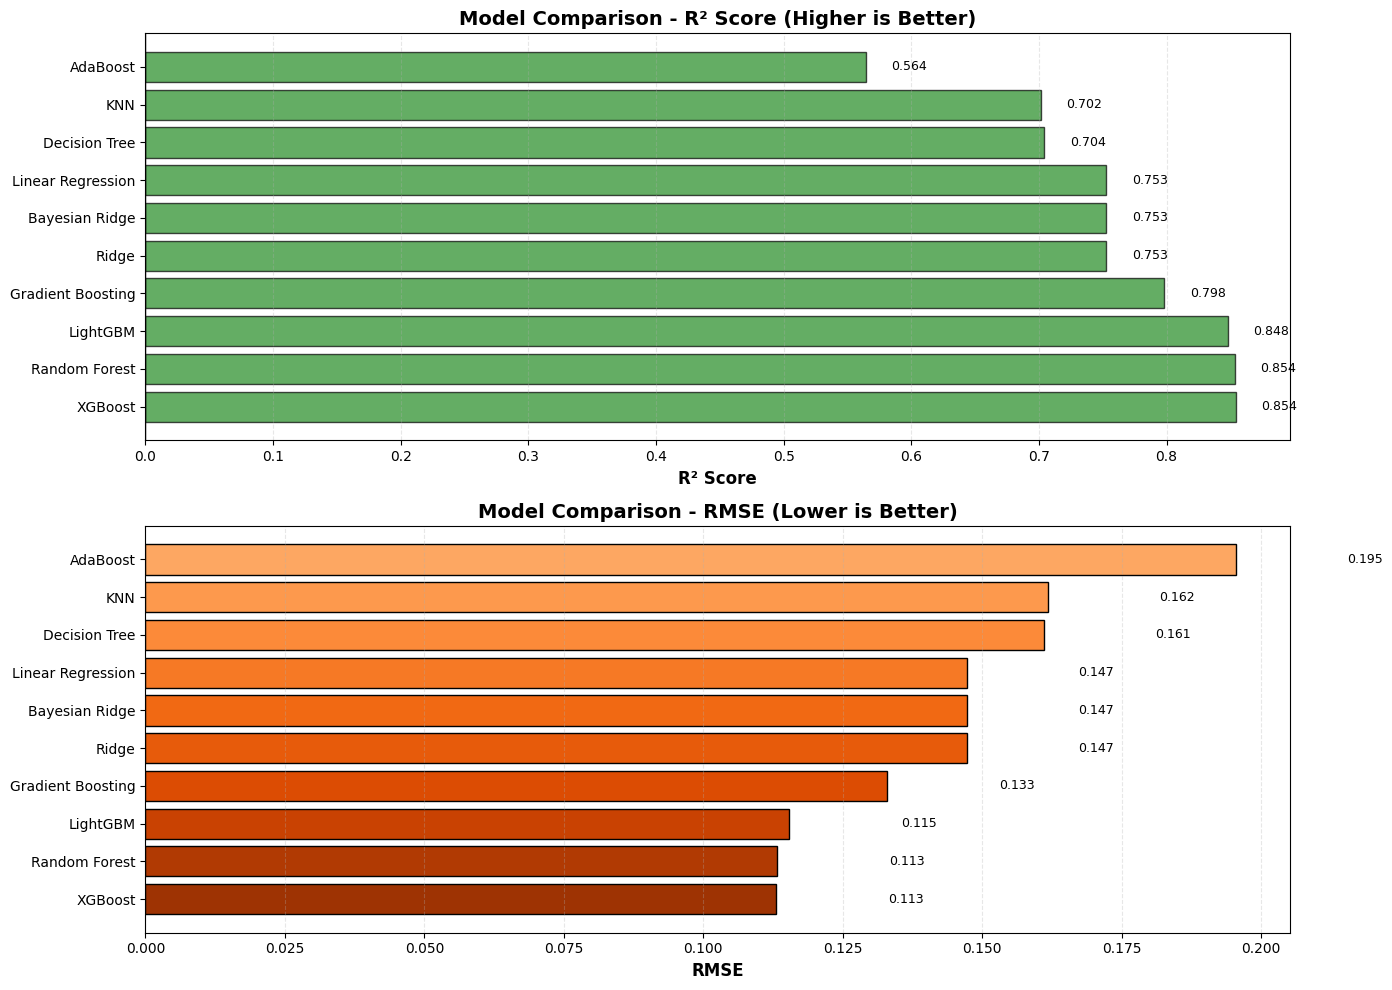

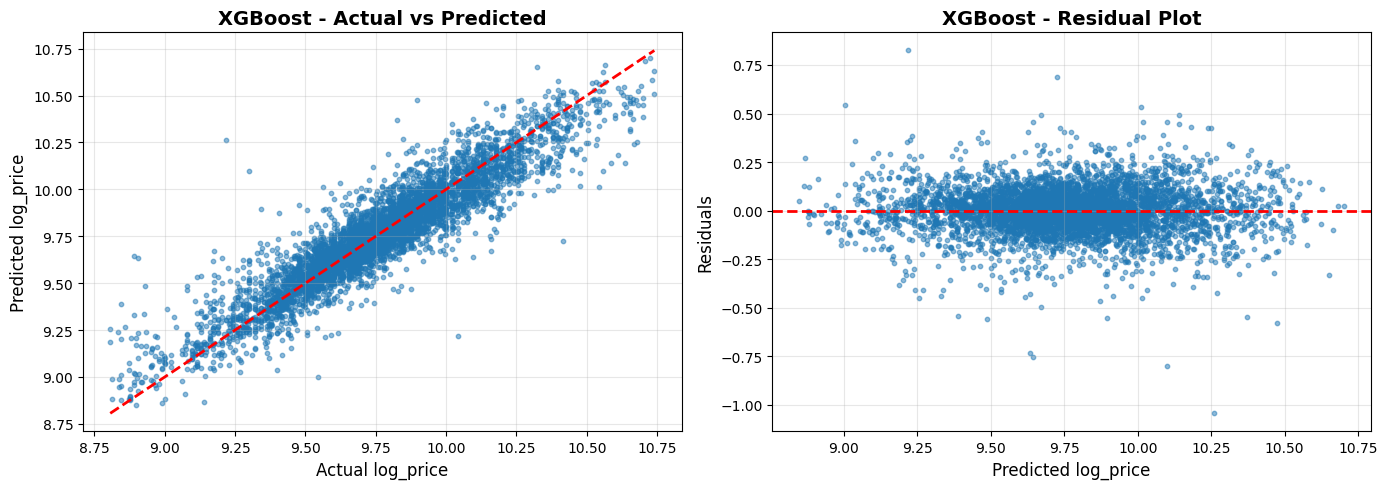

In [5]:
# Configuration
DATA_PATH = os.path.join(TRANSFORM_DATA_DIR, 's_listing_cleaned.csv')
TEST_SIZE = 0.2
TOP_N_FOR_TUNING = 1
TAG_NAME = "s_cleaned"

print("=" * 80)
print("REAL ESTATE PRICE PREDICTION - LINEAR REGRESSION MODELS")
print("Buy/Sell Cleaned Dataset")
print("=" * 80)

# Initialize predictor
predictor = RealEstatePricePredictor(DATA_PATH)

# Execute pipeline
predictor.load_data()
predictor.preprocess_data(test_size=TEST_SIZE)
predictor.define_models()
predictor.train_and_evaluate()

# Display results
summary_df = predictor.display_results_summary()

# Grid search on top models
tuned_results = predictor.grid_search_top_models(top_n=TOP_N_FOR_TUNING)

# Generate plots
# Option 1: Show only top 10 models
predictor.plot_results(save_path=f'{TAG_NAME}_model_comparison_top10.png', top_n=10)

# Option 2: Show only models with R² > 0 (filter out negative R²)
predictor.plot_results(save_path=f'{TAG_NAME}_model_comparison_positive.png', r2_threshold=0.0)

predictor.plot_predictions(save_path=f'{TAG_NAME}_predictions_plot.png')

# Save best model
predictor.save_best_model(filepath=f'{TAG_NAME}_best_model.pkl')

print("\n" + "=" * 80)
print("TRAINING PIPELINE COMPLETED SUCCESSFULLY!")
print("=" * 80)

## Dữ liệu làm sạch + đặc trưng tiện ích

REAL ESTATE PRICE PREDICTION - LINEAR REGRESSION MODELS
Buy/Sell Cleaned and Amenities Dataset
LOADING DATA
Dataset shape: (28690, 49)

Target variable (log_price) statistics:
count    28690.000000
mean         9.762696
std          0.298081
min          8.802774
25%          9.591065
50%          9.759668
75%          9.929419
max         10.740363
Name: log_price, dtype: float64

Missing values summary:
floornumber       27914
living_size       18163
floors            15612
length             8436
width              7860
is_main_street     7771
dtype: int64

FEATURE DETECTION
Numeric features (34): ['floornumber', 'floors', 'length', 'living_size', 'width', 'log_size', 'dist_center_km', 'dist_min_cho_km', 'dist_min_sieu_thi_km', 'dist_min_sieu_thi_mini_km', 'dist_min_cua_hang_tien_loi_km', 'dist_min_truong_mam_non_km', 'dist_min_truong_tieu_hoc_km', 'dist_min_truong_thpt_km', 'dist_min_truong_ai_hoc_km', 'dist_min_benh_vien_km', 'dist_min_tram_y_te_km', 'dist_min_cong_vien_km', 'dist

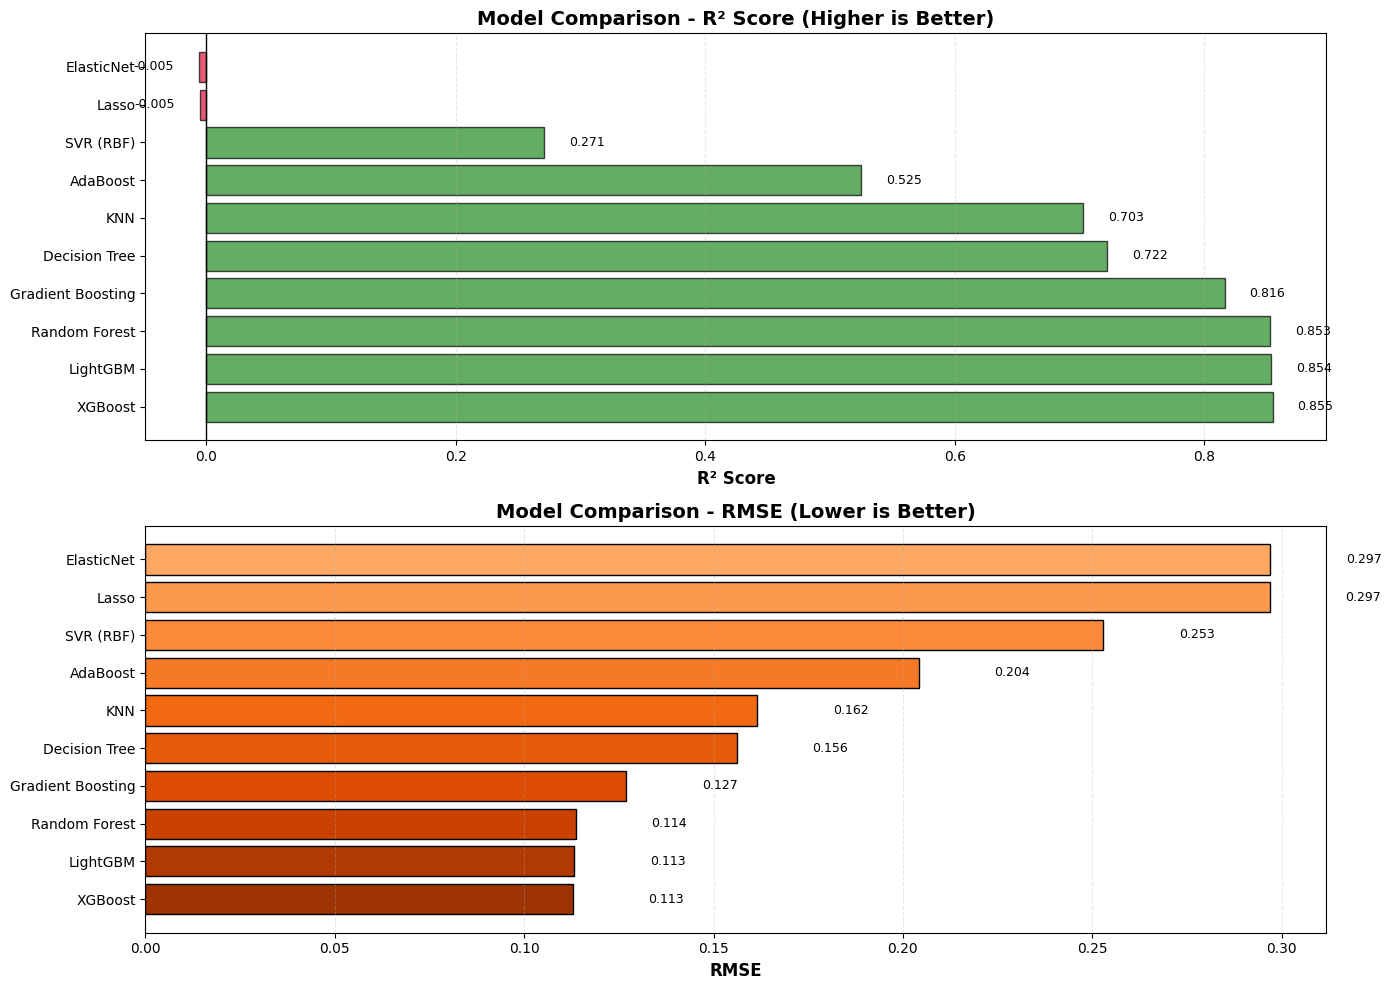

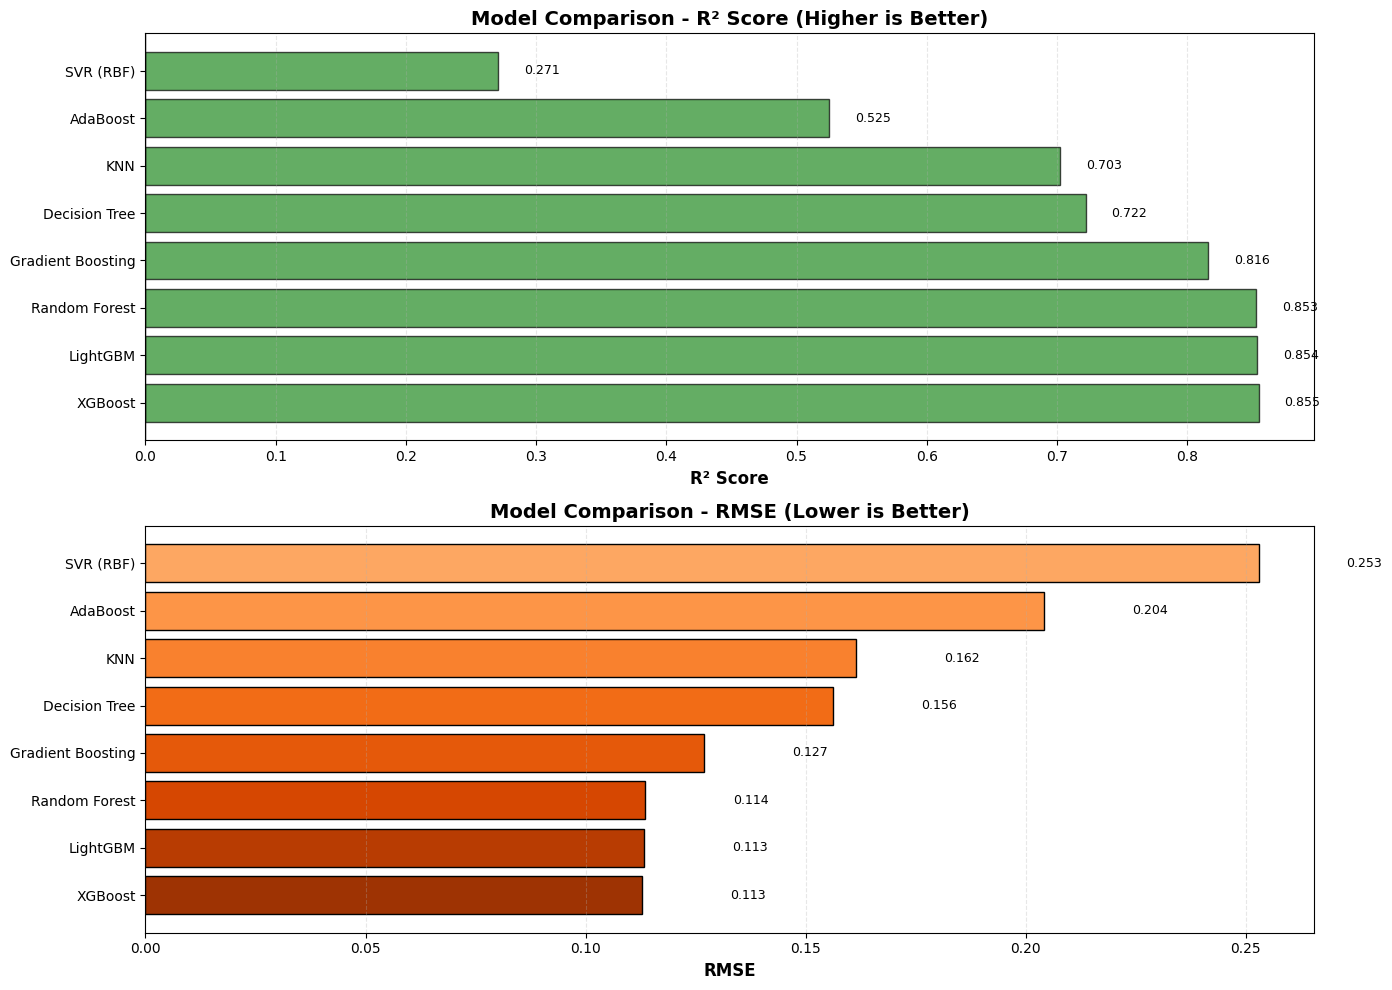

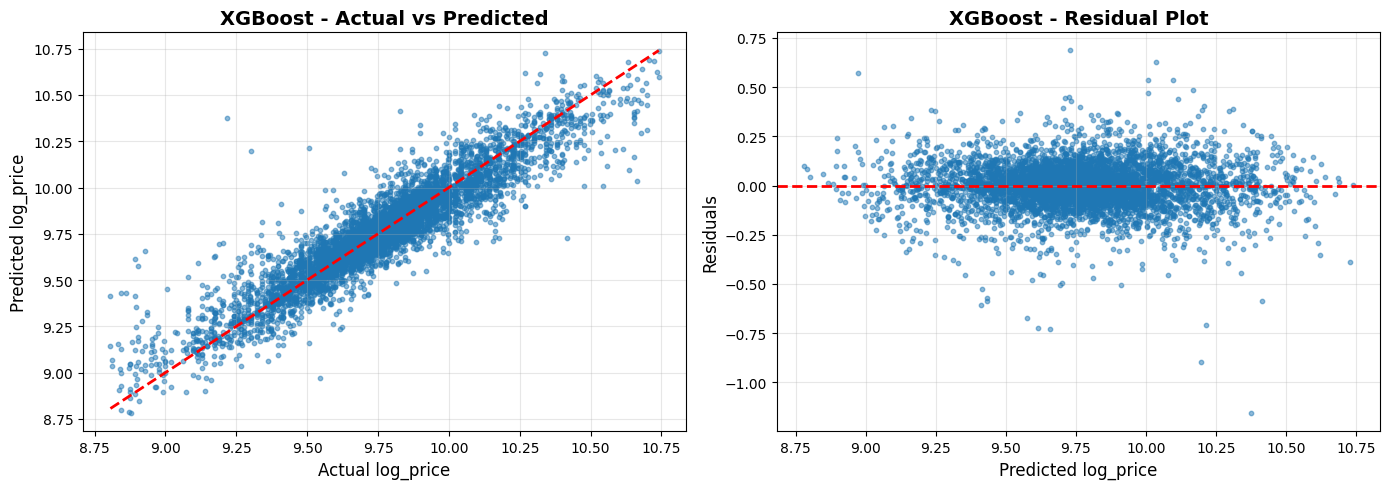

In [6]:
# Configuration
DATA_PATH = os.path.join(TRANSFORM_DATA_DIR, 's_listing_with_features.csv')
TEST_SIZE = 0.2
TOP_N_FOR_TUNING = 1
TAG_NAME = "s_with_features"

print("=" * 80)
print("REAL ESTATE PRICE PREDICTION - LINEAR REGRESSION MODELS")
print("Buy/Sell Cleaned and Amenities Dataset")
print("=" * 80)

# Initialize predictor
predictor = RealEstatePricePredictor(DATA_PATH)

# Execute pipeline
predictor.load_data()
predictor.preprocess_data(test_size=TEST_SIZE)
predictor.define_models()
predictor.train_and_evaluate()

# Display results
summary_df = predictor.display_results_summary()

# Grid search on top models
tuned_results = predictor.grid_search_top_models(top_n=TOP_N_FOR_TUNING)

# Generate plots
# Option 1: Show only top 10 models
predictor.plot_results(save_path=f'{TAG_NAME}_model_comparison_top10.png', top_n=10)

# Option 2: Show only models with R² > 0 (filter out negative R²)
predictor.plot_results(save_path=f'{TAG_NAME}_model_comparison_positive.png', r2_threshold=0.0)

predictor.plot_predictions(save_path=f'{TAG_NAME}_predictions_plot.png')

# Save best model
predictor.save_best_model(filepath=f'{TAG_NAME}_best_model.pkl')

print("\n" + "=" * 80)
print("TRAINING PIPELINE COMPLETED SUCCESSFULLY!")
print("=" * 80)

# Huấn luyện với dữ liệu cho thuê (u)

## Dữ liệu làm sạch

REAL ESTATE PRICE PREDICTION - LINEAR REGRESSION MODELS
Rent Cleaned Dataset
LOADING DATA
Dataset shape: (37882, 23)

Target variable (log_price) statistics:
count    37882.000000
mean         6.966335
std          0.471868
min          0.000000
25%          6.633468
50%          6.875061
75%          7.217484
max         11.414973
Name: log_price, dtype: float64

Missing values summary:
floornumber       36359
floors            33357
living_size       33047
length            30556
width             30514
is_main_street    10607
latitude             11
longitude            11
area_name             1
log_size              1
dtype: int64

FEATURE DETECTION
Numeric features (10): ['floornumber', 'floors', 'length', 'living_size', 'width', 'longitude', 'latitude', 'deposit', 'log_size', 'is_good_room']

Categorical features (12): ['area_name', 'category_name', 'is_main_street', 'apartment_type_name', 'rooms_count', 'toilets_count', 'furnishing_rent_status', 'balconydirection_name', 'direct

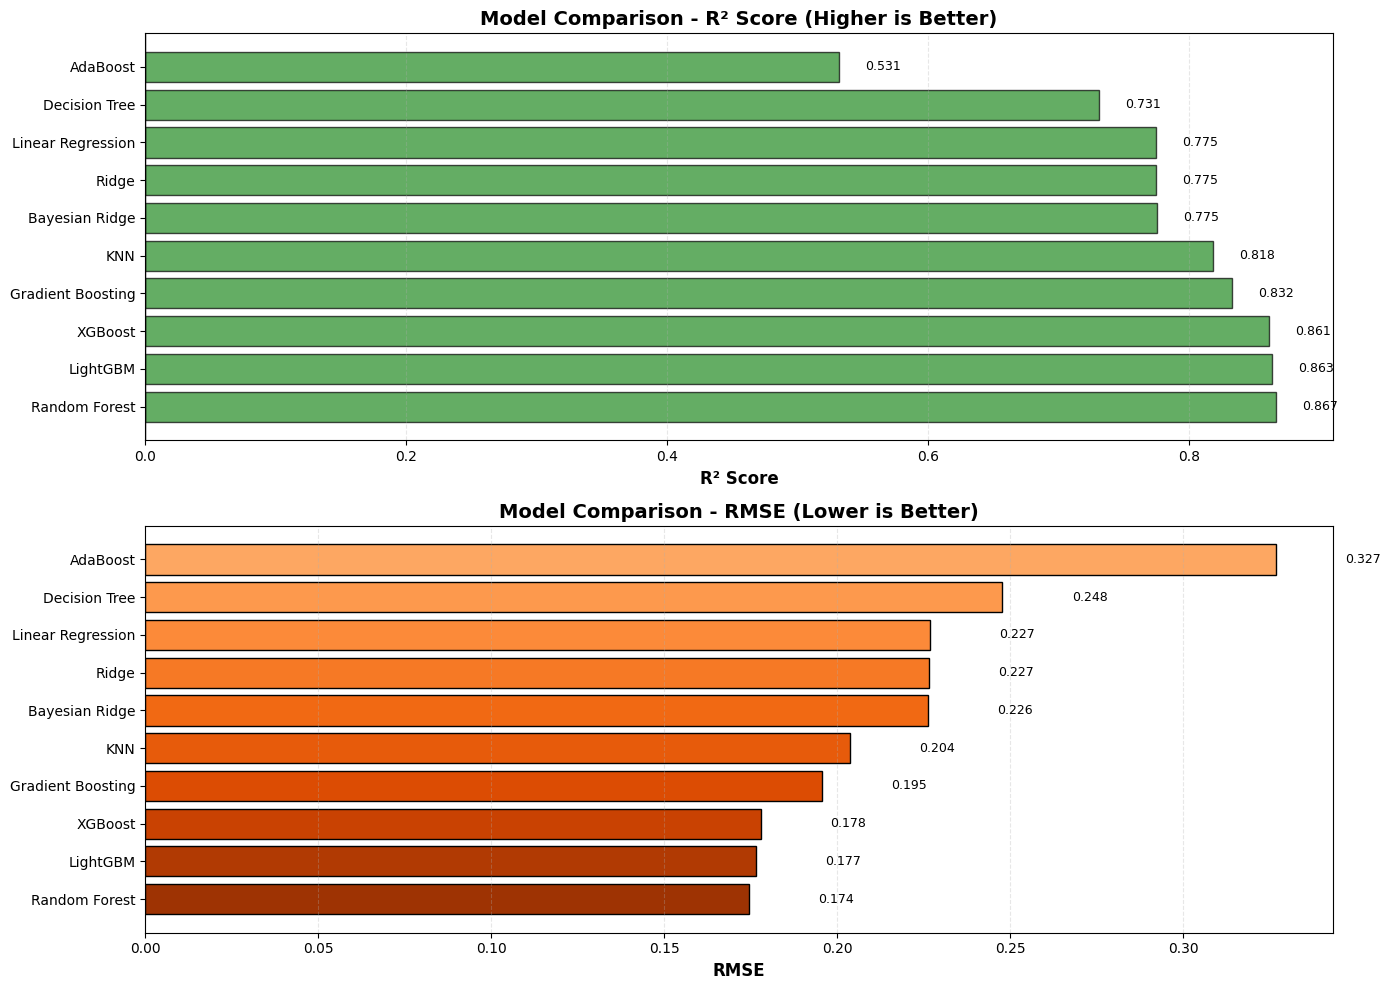

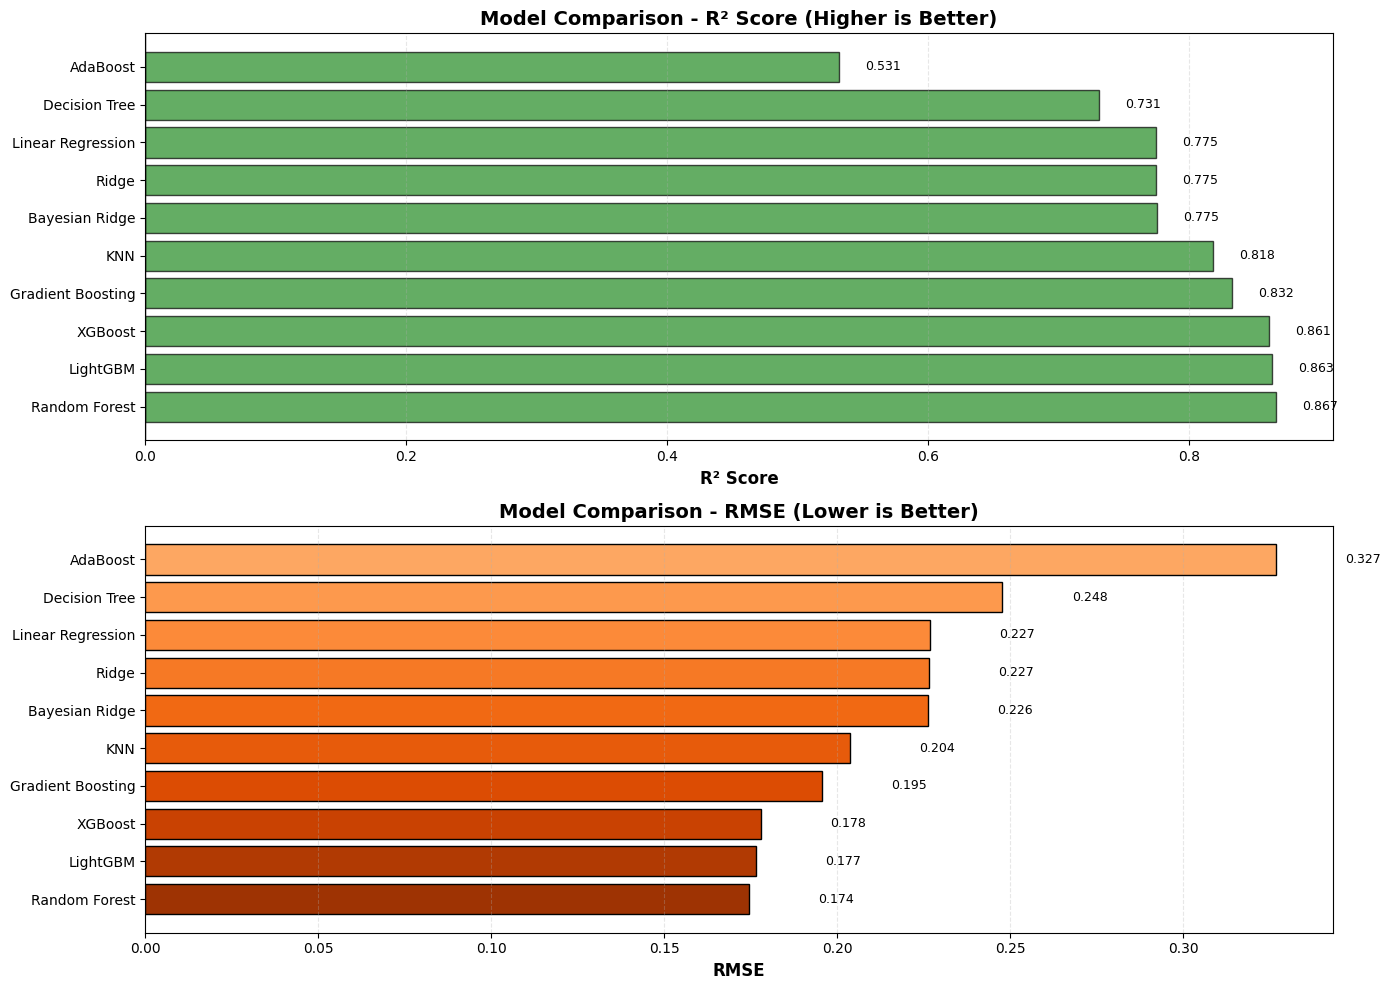

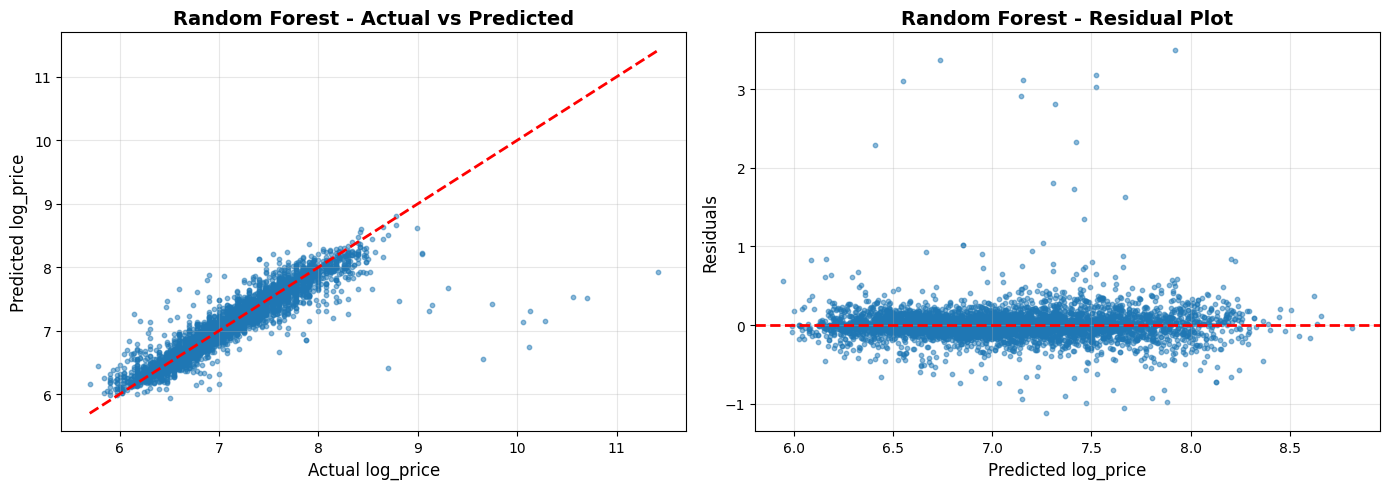

In [7]:
# Configuration
DATA_PATH = os.path.join(TRANSFORM_DATA_DIR, 'u_listing_cleaned.csv')
TEST_SIZE = 0.2
TOP_N_FOR_TUNING = 1
TAG_NAME = "u_cleaned"

print("=" * 80)
print("REAL ESTATE PRICE PREDICTION - LINEAR REGRESSION MODELS")
print("Rent Cleaned Dataset")
print("=" * 80)

# Initialize predictor
predictor = RealEstatePricePredictor(DATA_PATH)

# Execute pipeline
predictor.load_data()
predictor.preprocess_data(test_size=TEST_SIZE)
predictor.define_models()
predictor.train_and_evaluate()

# Display results
summary_df = predictor.display_results_summary()

# Grid search on top models
tuned_results = predictor.grid_search_top_models(top_n=TOP_N_FOR_TUNING)

# Generate plots
# Option 1: Show only top 10 models
predictor.plot_results(save_path=f'{TAG_NAME}_model_comparison_top10.png', top_n=10)

# Option 2: Show only models with R² > 0 (filter out negative R²)
predictor.plot_results(save_path=f'{TAG_NAME}_model_comparison_positive.png', r2_threshold=0.0)

predictor.plot_predictions(save_path=f'{TAG_NAME}_predictions_plot.png')

# Save best model
predictor.save_best_model(filepath=f'{TAG_NAME}_best_model.pkl')

print("\n" + "=" * 80)
print("TRAINING PIPELINE COMPLETED SUCCESSFULLY!")
print("=" * 80)

## Dữ liệu làm sạch + đặc trưng tiện ích

In [ ]:
# Configuration
DATA_PATH = os.path.join(TRANSFORM_DATA_DIR, 'u_listing_with_features.csv')
TEST_SIZE = 0.2
TOP_N_FOR_TUNING = 1
TAG_NAME = "u_with_features"

print("=" * 80)
print("REAL ESTATE PRICE PREDICTION - LINEAR REGRESSION MODELS")
print("Rent Cleaned and Amenities Dataset")
print("=" * 80)

# Initialize predictor
predictor = RealEstatePricePredictor(DATA_PATH)

# Execute pipeline
predictor.load_data()
predictor.preprocess_data(test_size=TEST_SIZE)
predictor.define_models()
predictor.train_and_evaluate()

# Display results
summary_df = predictor.display_results_summary()

# Grid search on top models
tuned_results = predictor.grid_search_top_models(top_n=TOP_N_FOR_TUNING)

# Generate plots
# Option 1: Show only top 10 models
predictor.plot_results(save_path=f'{TAG_NAME}_model_comparison_top10.png', top_n=10)

# Option 2: Show only models with R² > 0 (filter out negative R²)
predictor.plot_results(save_path=f'{TAG_NAME}_model_comparison_positive.png', r2_threshold=0.0)

predictor.plot_predictions(save_path=f'{TAG_NAME}_predictions_plot.png')

# Save best model
predictor.save_best_model(filepath=f'{TAG_NAME}_best_model.pkl')

print("\n" + "=" * 80)
print("TRAINING PIPELINE COMPLETED SUCCESSFULLY!")
print("=" * 80)

REAL ESTATE PRICE PREDICTION - LINEAR REGRESSION MODELS
Rent Cleaned and Amenities Dataset
LOADING DATA
Dataset shape: (37871, 49)

Target variable (log_price) statistics:
count    37871.000000
mean         6.966395
std          0.471781
min          0.000000
25%          6.633468
50%          6.875061
75%          7.217484
max         11.414973
Name: log_price, dtype: float64

Missing values summary:
floornumber       36348
floors            33346
living_size       33037
length            30545
width             30503
is_main_street    10596
area_name             1
log_size              1
dtype: int64

FEATURE DETECTION
Numeric features (36): ['floornumber', 'floors', 'length', 'living_size', 'width', 'deposit', 'log_size', 'is_good_room', 'dist_center_km', 'dist_min_cho_km', 'dist_min_sieu_thi_km', 'dist_min_sieu_thi_mini_km', 'dist_min_cua_hang_tien_loi_km', 'dist_min_truong_mam_non_km', 'dist_min_truong_tieu_hoc_km', 'dist_min_truong_thpt_km', 'dist_min_truong_ai_hoc_km', 'dist_min